# Quantum Support Vector Machine (QSVM) using Fermionic Matchgates

This notebook demonstrates how to implement a Quantum Kernel Estimator using custom Fermionic Matchgates in PennyLane. We use the resulting quantum kernel to train a Support Vector Machine (SVM) on a binary subset of the classical Wine dataset.

## 1. Imports and Data Preparation
We start by importing the necessary libraries and formatting our dataset for binary classification.

In [1]:
import numpy as np
import pennylane as qml
from pennylane.operation import Operation
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

# Load dataset
wine = load_wine()
X = wine.data
y = wine.target

# Keep only classes 1 and 2 to create a binary classification task
mask = (y == 1) | (y == 2)
X_filtered = X[mask]
y_filtered = y[mask]

# Map labels to {0,1}
y_filtered = (y_filtered == 2).astype(int)

# Train/test split (90/10 split)
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, 
    y_filtered, 
    test_size=0.1, 
    random_state=42, 
    stratify=y_filtered
)

print(f"Train shapes: X={X_train.shape}, y={y_train.shape}")
print(f"Test shapes: X={X_test.shape}, y={y_test.shape}")

Train shapes: X=(107, 13), y=(107,)
Test shapes: X=(12, 13), y=(12,)


## 2. Custom Fermionic Matchgates
Here, we define custom PennyLane operations representing fermionic matchgates. These gates are parameterized nearest-neighbor two-qubit interactions. We define rotation matchgates (`MatchRyRy`, `MatchRzRz`) and entangling matchgates (`MatchZX`, `MatchHH`).

In [2]:
class MatchRyRy(Operation):
    """U(Ry(θ1), Ry(θ2)) - Fermionic rotation matchgate"""
    num_params = 2
    num_wires = 2
    par_domain = "R"
    grad_method = "F"

    @staticmethod
    def compute_matrix(*params):
        theta_1 = params[0] / 2
        theta_2 = params[1] / 2
        return np.array([
            [np.cos(theta_1), 0, 0, -np.sin(theta_1)],
            [0, np.cos(theta_2), -np.sin(theta_2), 0],
            [0, np.sin(theta_2), np.cos(theta_2), 0],
            [np.sin(theta_1), 0, 0, np.cos(theta_1)],
        ])

class MatchRzRz(Operation):
    """U(Rz(θ1), Rz(θ2)) - Fermionic rotation matchgate"""
    num_params = 2
    num_wires = 2
    par_domain = "R"
    grad_method = "F"

    @staticmethod
    def compute_matrix(*params):
        theta_1 = params[0] / 2
        theta_2 = params[1] / 2
        return np.array([
            [np.exp(-1j * theta_1), 0, 0, 0],
            [0, np.exp(-1j * theta_2), 0, 0],
            [0, 0, np.exp(1j * theta_2), 0],
            [0, 0, 0, np.exp(1j * theta_1)],
        ])

class MatchZX(Operation):
    """U(Z, X) - Entangling matchgate"""
    num_params = 0
    num_wires = 2
    par_domain = "R"
    grad_method = "F"
    
    @staticmethod
    def compute_matrix(*params):
        return np.array([
            [1, 0, 0, 0],
            [0, 0, 1, 0],
            [0, 1, 0, 0],
            [0, 0, 0, -1],
        ])

class MatchHH(Operation):
    """U(H, H) - Entangling matchgate"""
    num_params = 0
    num_wires = 2
    par_domain = "R"
    grad_method = "F"

    @staticmethod
    def compute_matrix(*params):
        h = 1 / np.sqrt(2)
        return np.array([
            [h, 0, 0, -h],
            [0, h, -h, 0],
            [0, h, h, 0],
            [h, 0, 0, h],
        ])

## 3. Quantum Circuit Architecture
We define a single block (layer) of our feature map circuit. The parameters passed into the circuit are an encoded combination of our classical data $x$ and random parameters $\theta_r$ via the equation: 

$$\theta = \frac{\pi}{2} \theta_r + \frac{\pi}{2} x$$

In [3]:
def compute_encoded_parameters(x: np.ndarray,
                               theta_random: np.ndarray,
                               layer_idx: int,
                               c_theta: float = np.pi / 2,
                               c_x: float = np.pi / 2) -> np.ndarray:
    """Encode classical data point x for a given layer."""
    theta_r = theta_random[layer_idx] # shape (2 * n_qubits,)
    n_params = len(theta_r)

    # Pad x to length n_params (zeros beyond n_features)
    x_padded = np.zeros(n_params)
    x_padded[:min(len(x), n_params)] = x[:n_params]

    # Combine random parameters and classical data
    theta = c_theta * theta_r + c_x * x_padded
    return theta

def circuit_layer(theta_encoded: np.ndarray,
                  n_qubits: int,
                  entangling_gate: str = "ZX"):
    """Applies one encoding layer of matchgates: RyRy → RzRz → entanglers."""
    
    # Block 1: Even wire pairings
    for pair_idx in range(0, n_qubits - 1, 2):
        MatchRyRy(theta_encoded[pair_idx], theta_encoded[pair_idx + 1], wires=[pair_idx, pair_idx + 1])
        
    for pair_idx in range(0, n_qubits - 1, 2):
        MatchRzRz(theta_encoded[pair_idx], theta_encoded[pair_idx + 1], wires=[pair_idx, pair_idx + 1])
        
    for pair_idx in range(0, n_qubits - 1, 2):
        if entangling_gate == "ZX":
            MatchZX(wires=[pair_idx, pair_idx + 1])
        elif entangling_gate == "HH":
            MatchHH(wires=[pair_idx, pair_idx + 1])
            
    # Block 2: Offset encoding
    for pair_idx in range(0, n_qubits - 1, 2):
        MatchRyRy(theta_encoded[n_qubits + pair_idx], theta_encoded[n_qubits + pair_idx + 1], wires=[pair_idx, pair_idx + 1])
        
    for pair_idx in range(0, n_qubits - 1, 2):
        MatchRzRz(theta_encoded[n_qubits + pair_idx], theta_encoded[n_qubits + pair_idx + 1], wires=[pair_idx, pair_idx + 1])

    # Odd wire pairings for entanglement
    for pair_idx in range(1, n_qubits - 1, 2):
        if entangling_gate == "ZX":
            MatchZX(wires=[pair_idx, pair_idx + 1])
        elif entangling_gate == "HH":
            MatchHH(wires=[pair_idx, pair_idx + 1])

## 4. Quantum Kernel Evaluation
We calculate the full kernel matrix $K(x_i, x_j) = |\langle 0|U^\dagger(x_j) U(x_i) |0\rangle|^2$. 
PennyLane's `@qml.adjoint` decorator makes the transition from $U \rightarrow U^\dagger$ mathematically rigorous and syntactically clean.

In [4]:
def compute_kernel_matrix_efficient(X_data: np.ndarray,
                                    n_qubits: int,
                                    entangling_gate: str = "ZX",
                                    seed: int = 42) -> np.ndarray:
    """Compute full kernel matrix K(x_i, x_j) using @qml.adjoint."""
    np.random.seed(seed)
    n_samples, n_features = X_data.shape

    # Dynamically determine depth based on feature size
    d = int(np.ceil(n_features / n_qubits))
    n_layers = d // 2
    params_per_layer = 2 * n_qubits
    total_params_needed = n_layers * params_per_layer
    padding_size = max(0, total_params_needed - n_features)

    # Initialize random parameters used in the data encoding strategy
    theta_random = np.random.uniform(0, 1, size=(n_layers, params_per_layer))

    print("=" * 60)
    print("Executing Fermionic Quantum Kernel Estimation")
    print("=" * 60)
    print(f"Samples: {n_samples} | Features: {n_features}")
    print(f"Qubits: {n_qubits} | Layers: {n_layers} | Total Params: {total_params_needed}")
    print("=" * 60)

    dev = qml.device("default.qubit", wires=n_qubits)
    
    @qml.qnode(dev)
    def kernel_circuit(x1_idx, x2_idx):
        x1, x2 = X_data[x1_idx], X_data[x2_idx]
        
        # Forward Pass: U(x1)
        for layer_idx in range(n_layers):
            theta = compute_encoded_parameters(x1, theta_random, layer_idx)
            circuit_layer(theta, n_qubits, entangling_gate)

        # Adjoint Pass: U†(x2)
        @qml.adjoint
        def apply_u_x2():
            for layer_idx in range(n_layers):
                theta = compute_encoded_parameters(x2, theta_random, layer_idx)
                circuit_layer(theta, n_qubits, entangling_gate)

        apply_u_x2()
        return qml.probs(wires=range(n_qubits))

    # Initialize kernel matrix
    K = np.zeros((n_samples, n_samples))

    # Populate upper triangle and mirror
    for i in range(n_samples):
        for j in range(i, n_samples):
            k_ij = kernel_circuit(i, j)[0] # Probability of measuring |0...0>
            K[i, j] = k_ij
            K[j, i] = k_ij
            
        if (i + 1) % max(1, n_samples // 5) == 0:
            print(f"[{i+1:3d}/{n_samples}] Rows processed...")

    return K

## 5. Training the Quantum SVM
With the kernel matrix calculated, we can pass it directly into a standard classical `sklearn` Support Vector Machine.

In [5]:
n_qubits = 4

# 1. Compute kernel on train set
K_train = compute_kernel_matrix_efficient(X_train, n_qubits=n_qubits, seed=42)

# 2. Train classical SVM
svm = SVC(kernel="precomputed")
svm.fit(K_train, y_train)
train_acc = svm.score(K_train, y_train)
print(f"\nTrain SVM accuracy: {train_acc:.3f}")

# 3. Compute test kernel and evaluate
# K_test[i, j] represents K(x_test_i, x_train_j)
X_all = np.vstack([X_train, X_test])
K_all = compute_kernel_matrix_efficient(X_all, n_qubits=n_qubits, seed=42)

n_train, n_test = X_train.shape[0], X_test.shape[0]
K_test = K_all[n_train : n_train + n_test, :n_train]

test_acc = svm.score(K_test, y_test)
print(f"\nTest SVM accuracy: {test_acc:.3f}")

Executing Fermionic Quantum Kernel Estimation
Samples: 107 | Features: 13
Qubits: 4 | Layers: 2 | Total Params: 16
[ 21/107] Rows processed...
[ 42/107] Rows processed...
[ 63/107] Rows processed...
[ 84/107] Rows processed...
[105/107] Rows processed...

Train SVM accuracy: 0.869
Executing Fermionic Quantum Kernel Estimation
Samples: 119 | Features: 13
Qubits: 4 | Layers: 2 | Total Params: 16
[ 23/119] Rows processed...
[ 46/119] Rows processed...
[ 69/119] Rows processed...
[ 92/119] Rows processed...
[115/119] Rows processed...

Test SVM accuracy: 0.917


## 6. Circuit Visualization
Here is a visualization of a single forward and adjoint pass representing $U^\dagger(x) U(x)$.

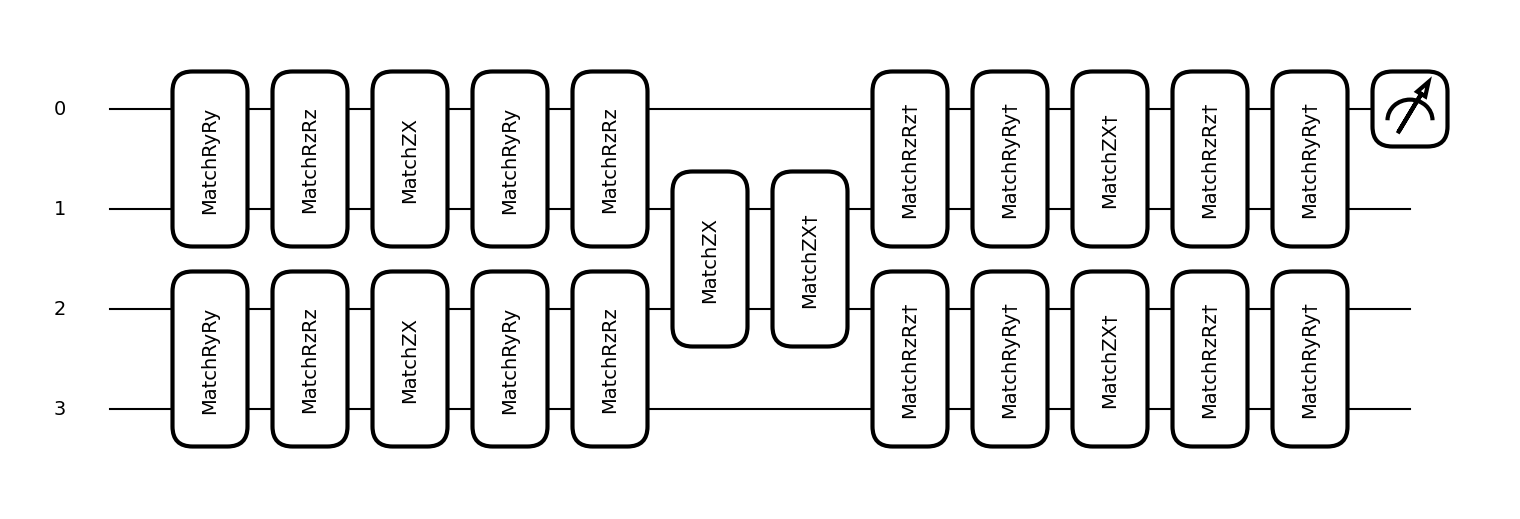

In [6]:
@qml.qnode(qml.device("default.qubit", wires=n_qubits))
def viz_circuit(params):
    circuit_layer(params, n_qubits=n_qubits, entangling_gate="ZX")
    qml.adjoint(circuit_layer)(params, n_qubits=n_qubits, entangling_gate="ZX")
    return qml.expval(qml.PauliZ(0))

# Generate dummy parameters corresponding to 1 layer
params_needed = 2 * n_qubits
dummy_params = np.random.randn(params_needed)

# Draw the circuit
fig, ax = qml.draw_mpl(viz_circuit)(dummy_params)
plt.show()